<a href="https://colab.research.google.com/github/trabajocientifico/ULTIMA-CLASE-ESPECIALIZACION/blob/main/AGRUPAMIENTO-K_VECINOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cargando datos desde el archivo de Excel...
¡Éxito! Se cargaron 150 registros de clientes.

Calculando el Método del Codo para hallar el K óptimo...


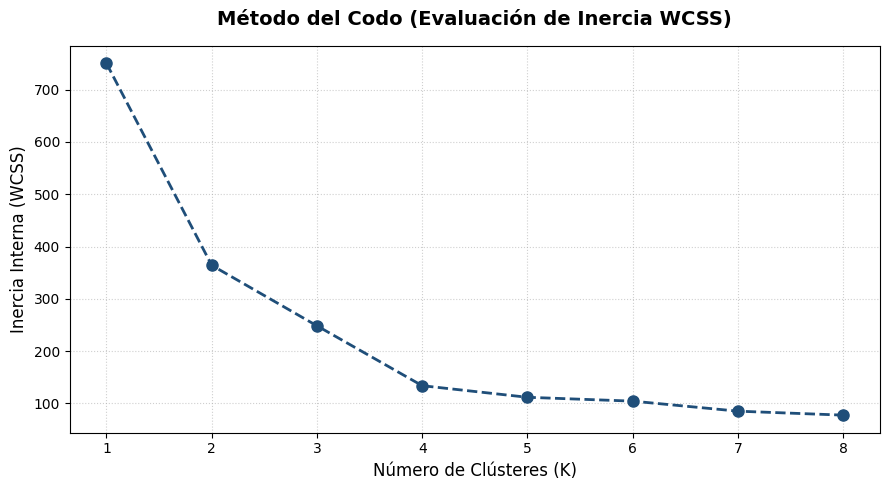

Entrenando el modelo final con K=4 clústeres...

MÉTRICA DE VALIDACIÓN:
Coeficiente de Silueta General: 0.5381



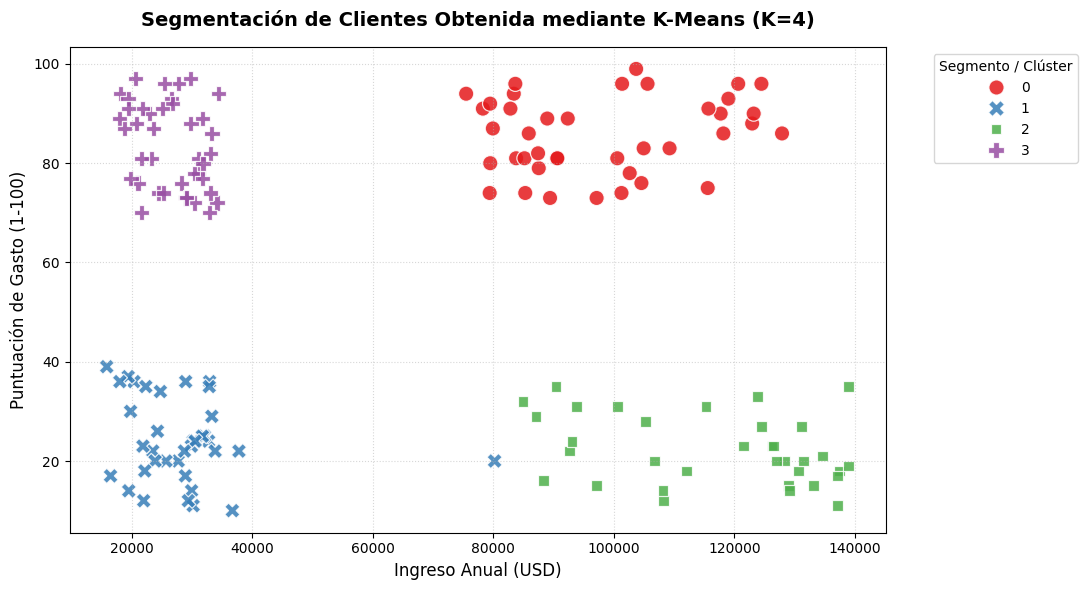

PERFIL PROMEDIO DE CADA SEGMENTO ENCONTRADO:
         Edad Promedio  Ingreso Anual Prom. (USD)  Puntaje Gasto (1-100)  Compras al Año  Días Última Compra
Cluster                                                                                                     
0                 41.2                    98149.9                   85.6            27.6                 4.9
1                 35.7                    28319.1                   24.2             5.6                38.8
2                 52.7                   116786.7                   22.3             6.4                54.9
3                 23.8                    26467.7                   83.7            18.0                 8.9


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ==========================================
# 1. CARGA Y LIMPIEZA DE DATOS
# ==========================================
print("Cargando datos desde el archivo de Excel...")
try:
    # Leer la pestaña específica de los datos
    df = pd.read_excel('Simulacion_Empresa_KMeans.xlsx', sheet_name='Datos_Clientes')

    # Eliminar la fila de 'Promedio General' del final para no alterar el modelo
    df['ID_Cliente'] = pd.to_numeric(df['ID_Cliente'], errors='coerce')
    df = df.dropna(subset=['ID_Cliente']).reset_index(drop=True)
    df['ID_Cliente'] = df['ID_Cliente'].astype(int)

    print(f"¡Éxito! Se cargaron {df.shape[0]} registros de clientes.\n")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'Simulacion_Empresa_KMeans.xlsx'.")
    print("Asegúrate de guardarlo en la misma carpeta que este script.")
    exit()

# Seleccionar las variables numéricas para el algoritmo
features = ['Edad', 'Ingreso_Anual_USD', 'Puntuacion_Gasto_1_100', 'Compras_Al_Ano', 'Dias_Ultima_Compra']
X = df[features]

# ==========================================
# 2. ESCALAMIENTO / ESTANDARIZACIÓN
# ==========================================
# K-Means depende de distancias. Escalamos los datos para que tengan media=0 y varianza=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. MÉTRICA 1: MÉTODO DEL CODO (ELBOW METHOD)
# ==========================================
print("Calculando el Método del Codo para hallar el K óptimo...")
wcss = []
k_valores = range(1, 9)

for k in k_valores:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # Inertia es la suma de cuadrados internos (WCSS)

# Gráfico 1: Método del Codo
plt.figure(figsize=(9, 5))
plt.plot(k_valores, wcss, marker='o', linestyle='--', color='#1F4E79', linewidth=2, markersize=8)
plt.title('Método del Codo (Evaluación de Inercia WCSS)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia Interna (WCSS)', fontsize=12)
plt.xticks(k_valores)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 4. ENTRENAMIENTO DEL MODELO ÓPTIMO (K=4)
# ==========================================
k_optimo = 4
print(f"Entrenando el modelo final con K={k_optimo} clústeres...")
kmeans_final = KMeans(n_clusters=k_optimo, init='k-means++', random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# ==========================================
# 5. MÉTRICA 2: COEFICIENTE DE SILUETA
# ==========================================
score_silueta = silhouette_score(X_scaled, df['Cluster'])
print("\n" + "="*50)
print(f"MÉTRICA DE VALIDACIÓN:")
print(f"Coeficiente de Silueta General: {score_silueta:.4f}")
print("="*50 + "\n")

# ==========================================
# 6. VISUALIZACIÓN GRÁFICA DE LOS CLÚSTERES
# ==========================================
plt.figure(figsize=(11, 6))

# Paleta de colores corporativa y clara
colores = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3']

sns.scatterplot(
    x='Ingreso_Anual_USD',
    y='Puntuacion_Gasto_1_100',
    hue='Cluster',
    palette=colores[:k_optimo],
    data=df,
    s=120,
    alpha=0.85,
    edgecolor='w',
    style='Cluster'
)

plt.title('Segmentación de Clientes Obtenida mediante K-Means (K=4)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ingreso Anual (USD)', fontsize=12)
plt.ylabel('Puntuación de Gasto (1-100)', fontsize=12)
plt.legend(title='Segmento / Clúster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# 7. PERFILAMIENTO / INTERPRETACIÓN COMERCIAL
# ==========================================
print("PERFIL PROMEDIO DE CADA SEGMENTO ENCONTRADO:")
perfiles = df.groupby('Cluster')[features].mean().round(1)

# Renombrar columnas para facilitar lectura en el reporte final
perfiles.columns = ['Edad Promedio', 'Ingreso Anual Prom. (USD)', 'Puntaje Gasto (1-100)', 'Compras al Año', 'Días Última Compra']
print(perfiles.to_string())